# TFM : Título del TFM
### Autores:
- ####  Adrian
- ####  Carlos Mendívil Gómez
- ####  Guillermo
- ####  Jose






#### Descripcion:

#### Carga de datos
Tres opciones:
- Webscrapping
- API
- csv iniciales

In [ ]:
#librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import requests
import re
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers




**Opcion 1 (La mas probable seguro):** cargamos datos antiguos y datos actuales para identificar que inmuebles se han vendido y asi crear nuestra columna dependiente y la variable objetivo. Uso de Red neuronal para predecir futuros pisos al automatizar la recogida de datos. Opciones de modelo:

| Modelo                | Pros                                            | Contras                                          |
| --------------------- | ----------------------------------------------- | ------------------------------------------------ |
| **FT-Transformer**    | SOTA, mejor que MLP, usa atención, rápido       | Necesita algo de tuning, menos común que XGBoost |
| **TabNet**            | Selección automática de features, interpretable | Lento de entrenar, difícil de converger a veces  |
| **Red densa (MLP)**   | Rápido, fácil de implementar                    | Menor rendimiento sin mucho tuning               |
| **SAINT / MLP-Mixer** | Nuevas ideas, muy potente si hay mucho dato     | Más experimental, menos soporte y recursos       |

  Métricas que se pueden usar:

  - ROC-AUC: mejor que accuracy si hay desbalance.
  - Precision@k: útil si quieres saber si los mejores pisos realmente se venden.
  - SHAP: interpretabilidad (FT-Transformer tiene soporte parcial).

Tras ello crear un modelo de IA generativa que pueda aconsejar al cliente. Pasos para ello:
  - 1 - Entrenar y guardar el modelo de clasificación con probabilidad de venta.
Guardar la tabla de resultados con prob_vendido.
  - 2 - Función de parsing del texto del cliente a filtros (NLU).
  - 3 -Filtro sobre el dataset para quedarte con “buenas ofertas” + matching con las preferencias del cliente.
  - 4 -LLM que toma el texto del cliente + ofertas y genera una recomendación.

(Opcional) UI: chatbot o aplicación. (No creo que de tiempo pero por soñar...)


**Opcion 2:** A partir de los datos más actuales determinamos las variables independientes mas importantes para definirlas como parametros a la hora de representar cada una de las filas (los pisos) en un hiperplano (como el clustering) y así poder clasificar cual de ellos es mejor. Luego continuariamos igual con lo de la IA generativa.

------------------
Como opcional si aparece una columna con opiniones o criticas podriamos realizar clasificaciones de texto para cambiar la columna con un int del 1 al 5 segun reseñas positivas o reseñas negativas.

In [5]:
# URLs base
repo_html_url = "https://github.com/guille1006/TFM/tree/main/Idealista/datos"
raw_base = "https://raw.githubusercontent.com/guille1006/TFM/main/Idealista/datos/"

# Obtener lista de archivos
html = requests.get(repo_html_url).text
csv_files = re.findall(r'datos_pag_\d+\.csv', html)
csv_files = sorted(set(csv_files))
len(csv_files)

498

In [ ]:

if not csv_files:
    raise ValueError("No se encontraron archivos CSV.")

print(f"🔍 Archivos encontrados: {len(csv_files)}")

dataframes = []
column_sets = {}
errores = []

# Leer archivos válidos
for file in csv_files:
    file_url = raw_base + file
    print(f"📥 Descargando: {file_url}")
    try:
        resp = requests.get(file_url)
        resp.raise_for_status()
        content = resp.text.strip()

        if not content:
            errores.append((file, "Archivo vacío"))
            continue

        df = pd.read_csv(StringIO(content))

        if df.empty:
            errores.append((file, "Sin datos"))
            continue

        dataframes.append((file, df))
        column_sets[file] = set(df.columns)

    except pd.errors.EmptyDataError:
        errores.append((file, "EmptyDataError"))
    except Exception as e:
        errores.append((file, str(e)))

# Obtener conjunto total de columnas encontradas
all_columns = set()
for cols in column_sets.values():
    all_columns.update(cols)

# Mostrar discrepancias de columnas por archivo con número de filas
print("\n🔎 Revisión de columnas por archivo:")
if column_sets:
    base_columns = column_sets[list(column_sets.keys())[0]]  # primer archivo válido
    for file, cols in column_sets.items():
        n_rows = None
        # Buscar número de filas en dataframes (que tiene (file, df))
        for f, df in dataframes:
            if f == file:
                n_rows = len(df)
                break
        if cols != base_columns:
            missing = base_columns - cols
            extra = cols - base_columns
            print(f"\n⚠️ {file} tiene discrepancias (filas: {n_rows}):")
            if missing:
                print(f"   ❌ Faltan columnas: {missing}")
            if extra:
                print(f"   ➕ Columnas extra: {extra}")
else:
    print("❌ No se leyeron archivos válidos.")

print(f"\n📑 Total columnas combinadas (antes de limpieza): {len(all_columns)}")

# Normalizar columnas en todos los DataFrames
normalized_dfs = []
for file, df in dataframes:
    current_cols = set(df.columns)
    missing_cols = all_columns - current_cols

    # Agregar columnas faltantes con NaN
    for col in missing_cols:
        df[col] = pd.NA

    # Reordenar columnas para que estén iguales
    df = df.reindex(columns=sorted(all_columns))
    normalized_dfs.append(df)

# Unión final
combined_df = pd.concat(normalized_dfs, ignore_index=True, sort=False)

print(f"\n✅ Archivos combinados: {len(normalized_dfs)}")
print(f"📊 Filas totales: {combined_df.shape[0]}")
print(f"📑 Columnas finales: {combined_df.columns.tolist()}")

# Mostrar errores
if errores:
    print("\n📛 Archivos con errores:")
    for file, msg in errores:
        print(f"  - {file}: {msg}")


In [7]:
combined_df.to_csv("Idealista/datos_juntos/datos_combinados.csv", index=False)

#### EDA/ limpieza de datos (si es necesario)

In [3]:
df_datos = combined_df.copy()
print(df_datos.shape)
df_datos.describe()

(21671, 49)


,bathrooms,latitude,longitude,numPhotos,parkingSpace.parkingSpacePrice,price,priceByArea,priceInfo.price.amount,priceInfo.price.priceDropInfo.formerPrice,priceInfo.price.priceDropInfo.priceDropPercentage,priceInfo.price.priceDropInfo.priceDropValue,propertyCode,rooms,size
count,21671.000000,21671.000000,21671.000000,21671.000000,328.000000,2.167100e+04,21671.000000,2.167100e+04,2.189000e+03,2189.000000,2189.000000,2.167100e+04,21671.000000,21671.000000
mean,2.331180,40.430773,-3.717232,27.546998,31857.310976,8.780367e+05,5062.095289,8.780367e+05,5.839238e+05,4.602101,27645.709456,1.073407e+08,3.160260,212.106668
std,1.564254,0.117400,0.169047,19.495802,21241.635501,1.193534e+06,3563.798676,1.193534e+06,5.860253e+05,3.102487,43945.555918,4.672519e+06,1.693311,1764.326158
min,0.000000,40.010758,-4.494274,0.000000,60.000000,1.100000e+04,17.000000,1.100000e+04,3.200000e+04,1.000000,1000.000000,4.600250e+05,0.000000,11.000000
25%,1.000000,40.385524,-3.771257,14.000000,15000.000000,2.550000e+05,2561.000000,2.550000e+05,2.390000e+05,3.000000,10000.000000,1.075127e+08,2.000000,76.000000
50%,2.000000,40.425758,-3.698546,24.000000,30000.000000,4.590000e+05,3828.000000,4.590000e+05,3.830000e+05,4.000000,15000.000000,1.083417e+08,3.000000,115.000000
75%,3.000000,40.465263,-3.653455,37.000000,40000.000000,1.000000e+06,6726.000000,1.000000e+06,7.200000e+05,6.000000,29500.000000,1.086816e+08,4.000000,213.000000
max,29.000000,41.106928,-3.071336,190.000000,100000.000000,1.850000e+07,37143.000000,1.850000e+07,7.500000e+06,45.000000,755200.000000,1.089514e+08,58.000000,150000.000000


#### Eliminar duplicados

In [ ]:
# Eliminamos duplicados
df_datos = df_datos.drop_duplicates()
print(df_datos.shape)

(17461, 49)


#### Valores nulos

In [ ]:
# Valores nulos
df_datos.isna().sum()

,0
address,0
bathrooms,0
country,0
description,27
detailedType.subTypology,11193
detailedType.typology,0
district,2429
exterior,4944
externalReference,4597
floor,5028


In [ ]:
for col in df_datos.columns:
    null_count = df_datos[col].isnull().sum()
    if null_count > 0:
        print(f"\n📌 Columna: {col} | Nulos: {null_count}")
        #print("🔹 Valores y frecuencias:")
        vc = df_datos[col].value_counts(dropna=False)
        #for val, freq in vc.items():
            #print(f"  - {repr(val)}: {freq}")



📌 Columna: description | Nulos: 27

📌 Columna: detailedType.subTypology | Nulos: 11193

📌 Columna: district | Nulos: 2429

📌 Columna: exterior | Nulos: 4944

📌 Columna: externalReference | Nulos: 4597

📌 Columna: floor | Nulos: 5028

📌 Columna: hasLift | Nulos: 4668

📌 Columna: highlight.groupDescription | Nulos: 10813

📌 Columna: neighborhood | Nulos: 6979

📌 Columna: newDevelopmentFinished | Nulos: 15678

📌 Columna: parkingSpace.hasParkingSpace | Nulos: 9617

📌 Columna: parkingSpace.isParkingSpaceIncludedInPrice | Nulos: 9617

📌 Columna: parkingSpace.parkingSpacePrice | Nulos: 17192

📌 Columna: priceInfo.price.priceDropInfo.formerPrice | Nulos: 15687

📌 Columna: priceInfo.price.priceDropInfo.priceDropPercentage | Nulos: 15687

📌 Columna: priceInfo.price.priceDropInfo.priceDropValue | Nulos: 15687

📌 Columna: status | Nulos: 385

📌 Columna: thumbnail | Nulos: 272


In [ ]:
df_datos_1 = df_datos.copy()

In [ ]:
#Variable externalReference
df_datos_1['externalReference'] = df_datos_1['externalReference'].fillna('unknown')

In [ ]:
#Variable floor
print(df_datos["propertyType"].value_counts(dropna=False))
df_datos.loc[df_datos_1['floor'].isna()].groupby('detailedType.typology'
  ).size().reset_index(name='count').sort_values(by='count', ascending=False)

propertyType
flat            11079
chalet           4401
penthouse         810
duplex            713
studio            318
countryHouse      140
Name: count, dtype: int64


,detailedType.typology,count
0,chalet,4401
2,flat,507
1,countryHouse,120


In [ ]:
df_datos_2 = df_datos_1.copy()

In [ ]:
# Cambiar 'bj' por '0'
df_datos_2['floor'] = df_datos_2['floor'].replace('bj', '0')

# Cambiar valores NaN a 'No' si la propiedad es chalet o countryHouse
df_datos_2.loc[
    df_datos_2['floor'].isna() & df_datos_2['propertyType'].isin(['chalet', 'countryHouse']),
    'floor'
] = 'No'

# Comprobar si quedan nulos
print(df_datos_2["floor"].value_counts(dropna=False))

floor
No      4521
1       2689
2       2215
0       1963
3       1911
4       1377
5        788
NaN      507
6        486
7        294
8        144
en       129
9         92
ss        54
10        42
st        32
3.0       28
2.0       28
-1        21
1.0       20
12        17
11        17
4.0       16
13        14
14        11
5.0        9
6.0        9
7.0        3
24         3
18         3
9.0        3
14.0       2
19         2
15         2
sm         2
23         1
22         1
12.0       1
24.0       1
+1         1
8.0        1
11.0       1
Name: count, dtype: int64


In [ ]:
df_datos_3 = df_datos_2.copy()

In [ ]:
df_datos["exterior"].value_counts(dropna=False)

,count
exterior,
True,11134
NaN,4944
False,1383


In [ ]:
df_datos["parkingSpace.hasParkingSpace"].value_counts(dropna=False)

,count
parkingSpace.hasParkingSpace,
NaN,9617
True,7844


In [ ]:
# Lista de columnas booleanas a convertir
bool_cols = [
    'exterior',
    'hasLift',
    'parkingSpace.hasParkingSpace',
    'parkingSpace.isParkingSpaceIncludedInPrice',
]

# Reemplazamos NaN por False y convertimos a binaria
df_datos_3[bool_cols] = (
    df_datos_3[bool_cols]
    .fillna(False)
    .astype(int)
)

/tmp/ipython-input-3318961306.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
df_datos_4 = df_datos_3.copy()

In [ ]:
#subTypology
df_datos['detailedType.subTypology'].value_counts(dropna=False)

,count
detailedType.subTypology,
independantHouse,20
NaN,19
penthouse,6
semidetachedHouse,3
terracedHouse,2


In [ ]:
df_datos[df_datos['propertyType'] == "flat"].shape[0]

19

In [ ]:
df_datos_4['detailedType.subTypology'].fillna('flat', inplace=True)

# district
df_datos_4['district'].fillna('unknown', inplace=True)
# neighborhood
df_datos_4['neighborhood'].fillna('unknown', inplace=True)

/tmp/ipython-input-2366503194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_datos_4['detailedType.subTypology'].fillna('flat', inplace=True)
/tmp/ipython-input-2366503194.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
df_datos_5 = df_datos_4.copy()

In [ ]:
# priceInfo

# formerPrice
df_datos_5.loc[df_datos_5['priceInfo.price.priceDropInfo.formerPrice'].isna(), 'priceInfo.price.priceDropInfo.formerPrice'] = \
  df_datos_5.loc[df_datos_5['priceInfo.price.priceDropInfo.formerPrice'].isna(), 'priceInfo.price.amount']

# priceDropValue
df_datos_5['priceInfo.price.priceDropInfo.priceDropValue'] = df_datos_5['priceInfo.price.priceDropInfo.priceDropValue'].fillna(0.0)
df_datos_5['priceInfo.price.priceDropInfo.priceDropPercentage'] = df_datos_5['priceInfo.price.priceDropInfo.priceDropPercentage'].fillna(0.0)

# parkingSpacePrice
df_datos_5['parkingSpace.parkingSpacePrice'] = df_datos_5['parkingSpace.parkingSpacePrice'].fillna(0.0)


In [ ]:
# Valores nulos
df_datos_5.isna().sum().sum()

np.int64(0)

### Estudiar formato variables

In [ ]:
# Obtener información de las columnas
variables = list(df_datos_5.columns)

info_types = pd.DataFrame(
    {"Tipo de columna": df_datos_5.dtypes, "Suma de valores únicos": df_datos_5.nunique()}
)

info_types

,Tipo de columna,Suma de valores únicos
thumbnail,object,50
externalReference,object,49
numPhotos,int64,33
floor,object,8
price,float64,40
propertyType,object,3
operation,object,1
size,float64,46
exterior,int64,2
rooms,int64,9


In [ ]:
#Variables a descartar
cols_to_drop = [
    'province',
    'country',
    'notes',
    'highlight.groupDescription',
    'thumbnail',
    'externalReference',
    'url',
    'description',
    "operation",
    "priceInfo.price.currencySuffix",
    "priceInfo.price.amount"
]

#Columnas a considerar:
#propertyCode, numPhotos, suggestedTexts.subtitle, 'suggestedTexts.title'

df_datos_6 =df_datos_5.copy()

# Eliminarlas del DataFrame
df_datos_6.drop(columns=cols_to_drop, inplace=True)

In [ ]:
#Categoricas
#Ya object = floor, propertyType, address, municipality, district, detailedType.typology, detailedType.subTypology, suggestedTexts.subtitle, suggestedTexts.title, neighborhood
categorical_cols = [
    'floor',
    'propertyType',
    'address',
    'municipality',
    'district',
    'detailedType.typology',
    'detailedType.subTypology',
    'suggestedTexts.subtitle',
    'suggestedTexts.title',
    'status',
    'neighborhood'
]

# Convertir a tipo categórico
df_datos_6[categorical_cols] = df_datos_6[categorical_cols].astype('object')

In [ ]:
df_datos_7 = df_datos_6.copy()

In [ ]:
#Numericas
#Ya numérica = numPhotos, price, size, exterior, rooms, bathrooms, latitude, longitude, hasLift, priceByArea, parkingSpace.hasParkingSpace, parkingSpace.isParkingSpaceIncludedInPrice
#priceInfo.price.priceDropInfo.formerPrice, priceInfo.price.priceDropInfo.priceDropValue, priceInfo.price.priceDropInfo.priceDropPercentage, parkingSpace.parkingSpacePrice
#Binarias a convertir = showAddress, hasVideo, status, newDevelopment, hasPlan, has3DTour, has360, hasStaging, topNewDevelopment, topPlus
#Revisar priceInfo.price.amount
# Columnas numéricas ya numéricas
numeric_cols = [
    'price',
    'size',
    'rooms',
    'bathrooms',
    'latitude',
    'longitude',
    'priceByArea',
    'priceInfo.price.priceDropInfo.formerPrice',
    'priceInfo.price.priceDropInfo.priceDropValue',
    'priceInfo.price.priceDropInfo.priceDropPercentage',
    'parkingSpace.parkingSpacePrice'
]
# Revisar si 'detailedType.typology' y tienen mas opciones o pueden convertirse a binaria 'status',

binary_cols = [
    'showAddress',
    'hasVideo',
    'newDevelopment',
    'hasPlan',
    'has3DTour',
    'has360',
    'hasStaging',
    'topNewDevelopment',
    'topPlus'
]

for col in binary_cols:
    df_datos_7[col] = df_datos_7[col].astype(str).str.strip().map({'True': 1, 'False': 0})


In [ ]:
df_datos_8 = df_datos_7.copy()

#var_obj = df_datos_8['vendido']
#df_datos_8.drop(columns=["vendido"], inplace=True)

#Establecemos las variables numéricas y las categóricas
variables_numericas = df_datos_8.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
variables_categoricas = df_datos_8.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

In [ ]:
# Obtener información de las columnas
variables = list(df_datos_8.columns)

info_types = pd.DataFrame(
    {"Tipo de columna": df_datos_8.dtypes, "Suma de valores únicos": df_datos_8.nunique()}
)

info_types

,Tipo de columna,Suma de valores únicos
numPhotos,int64,33
floor,object,8
price,float64,40
propertyType,object,3
size,float64,46
exterior,int64,2
rooms,int64,9
bathrooms,int64,10
address,object,46
municipality,object,5


#### Estudio de las variables categoricas

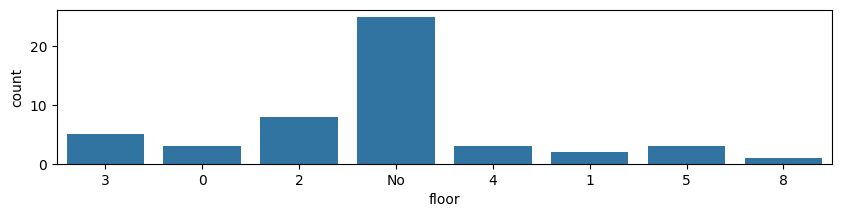

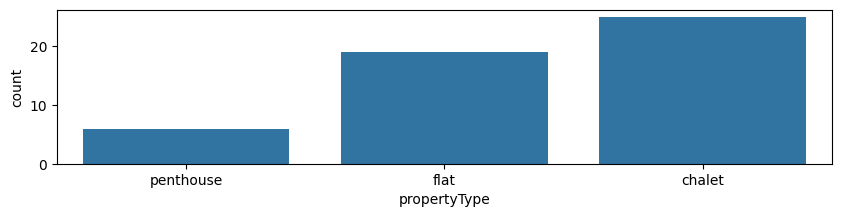

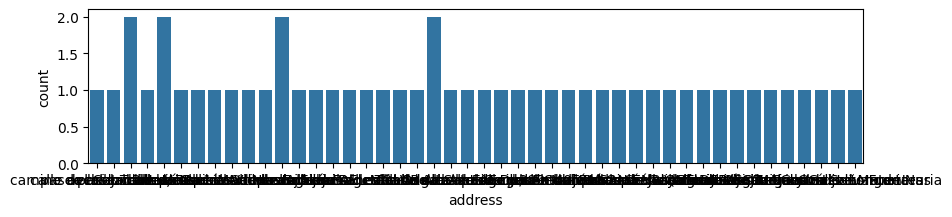

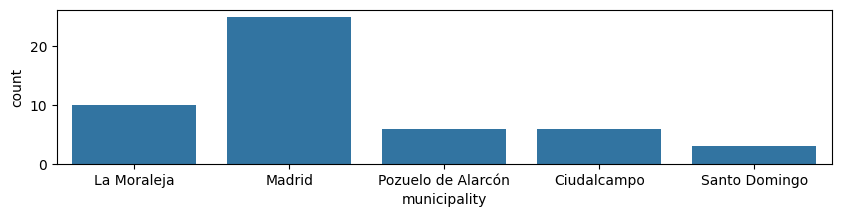

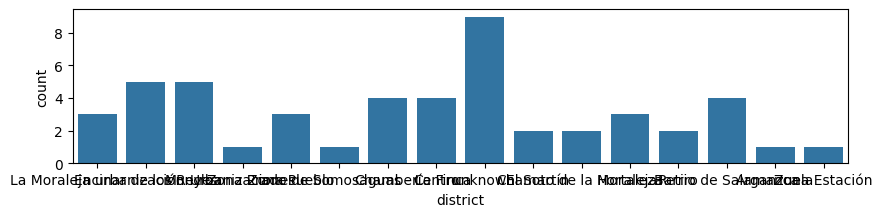

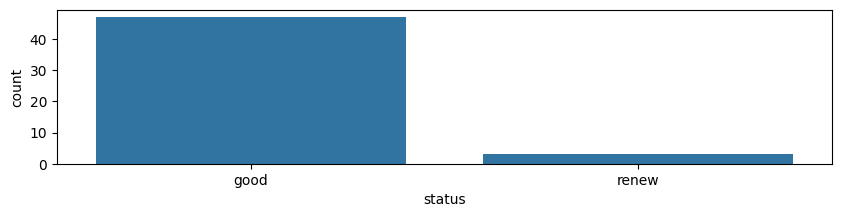

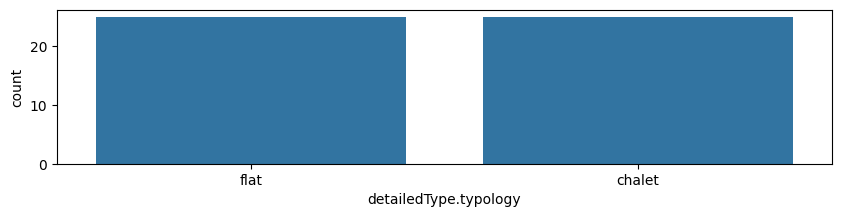

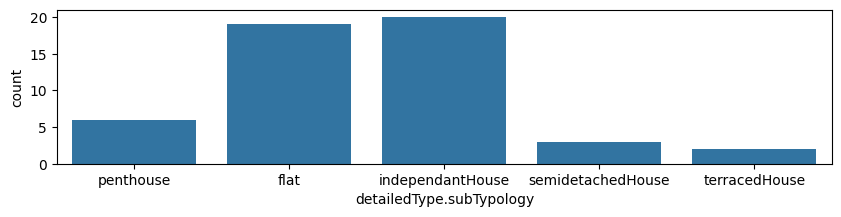

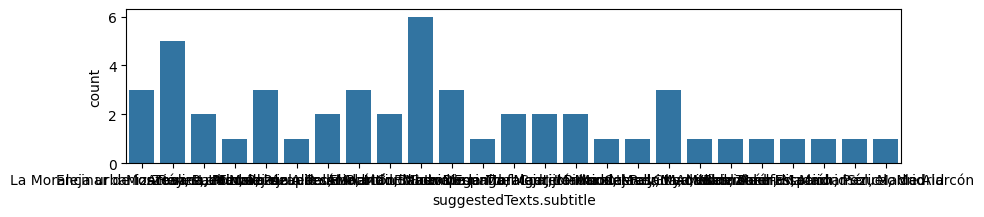

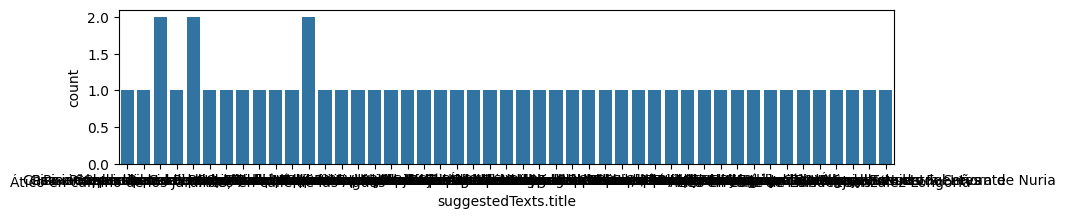

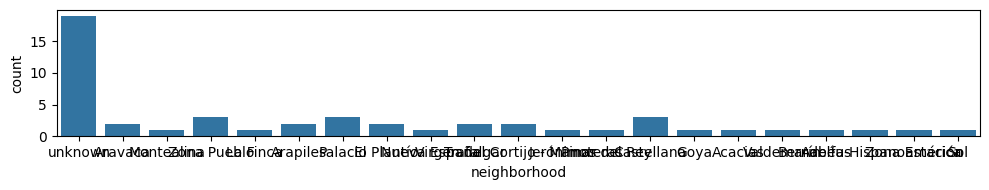

In [ ]:
#Estudio variables categóricas
for col in variables_categoricas:
    plt.figure(figsize=(10,2))
    sns.countplot(data=df_datos_8, x=col)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
"""
for col in variables_categoricas:
    plt.figure(figsize=(10, 2))
    sns.countplot(data=df_datos_8, x=col, hue=var_obj)

plt.tight_layout()
plt.savefig('vc.png', format='png', dpi=300)
plt.show()
plt.close()
"""

"\nfor col in variables_categoricas:\n    plt.figure(figsize=(10, 2))\n    sns.countplot(data=df_datos_8, x=col, hue=var_obj)\n\nplt.tight_layout()\nplt.savefig('vc.png', format='png', dpi=300)\nplt.show()\nplt.close()\n"

#### Estudio de las variables numéricas

In [ ]:
#Estudio variables numéricas
df_datos_8[variables_numericas].describe().T

,numPhotos,price,size,exterior,rooms,bathrooms,latitude,longitude,showAddress,hasVideo,...,has360,hasStaging,topNewDevelopment,topPlus,parkingSpace.hasParkingSpace,parkingSpace.isParkingSpaceIncludedInPrice,priceInfo.price.priceDropInfo.formerPrice,priceInfo.price.priceDropInfo.priceDropValue,priceInfo.price.priceDropInfo.priceDropPercentage,parkingSpace.parkingSpacePrice
count,50.000000,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0,...,50.0,50.000000,50.0,50.0,50.000000,50.000000,5.000000e+01,50.00000,50.000000,50.00000
mean,47.140000,2.506320e+06,476.600000,0.500000,4.560000,4.520000,40.487905,-3.688748,0.060000,1.0,...,0.0,0.820000,0.0,1.0,0.820000,0.780000,2.511780e+06,5460.00000,0.500000,1180.00000
std,20.987858,2.600497e+06,488.022875,0.505076,2.101117,2.581251,0.074551,0.075439,0.239898,0.0,...,0.0,0.388088,0.0,0.0,0.388088,0.418452,2.597521e+06,15550.06398,1.403349,6146.80936
min,25.000000,7.600000e+05,94.000000,0.000000,2.000000,1.000000,40.400874,-3.842666,0.000000,1.0,...,0.0,0.000000,0.0,1.0,0.000000,0.000000,7.600000e+05,0.00000,0.000000,0.00000
25%,33.250000,1.261250e+06,166.750000,0.000000,3.000000,3.000000,40.432296,-3.714051,0.000000,1.0,...,0.0,1.000000,0.0,1.0,1.000000,1.000000,1.261250e+06,0.00000,0.000000,0.00000
50%,43.000000,1.565000e+06,295.500000,0.500000,4.000000,4.000000,40.465472,-3.678491,0.000000,1.0,...,0.0,1.000000,0.0,1.0,1.000000,1.000000,1.565000e+06,0.00000,0.000000,0.00000
75%,51.000000,2.472500e+06,549.500000,1.000000,6.000000,5.750000,40.513639,-3.637307,0.000000,1.0,...,0.0,1.000000,0.0,1.0,1.000000,1.000000,2.472500e+06,0.00000,0.000000,0.00000
max,149.000000,1.500000e+07,2034.000000,1.000000,11.000000,11.000000,40.642865,-3.572435,1.000000,1.0,...,0.0,1.000000,0.0,1.0,1.000000,1.000000,1.500000e+07,60000.00000,6.000000,39000.00000


/tmp/ipython-input-2418648534.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 2))


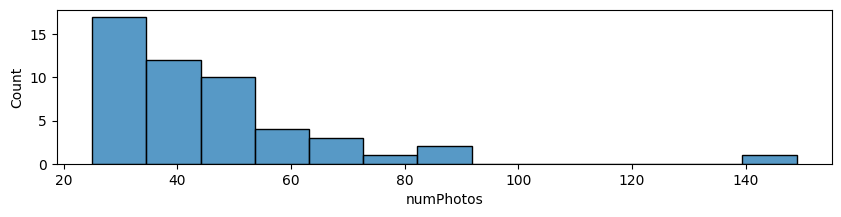

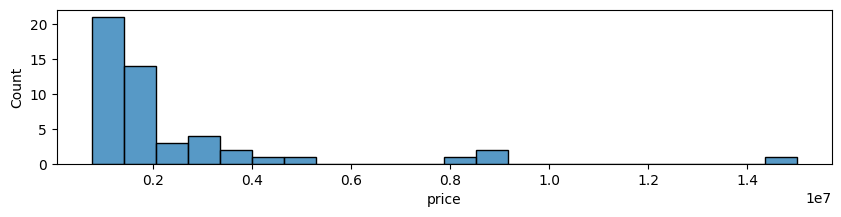

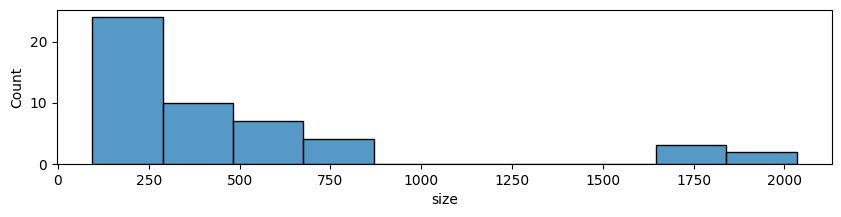

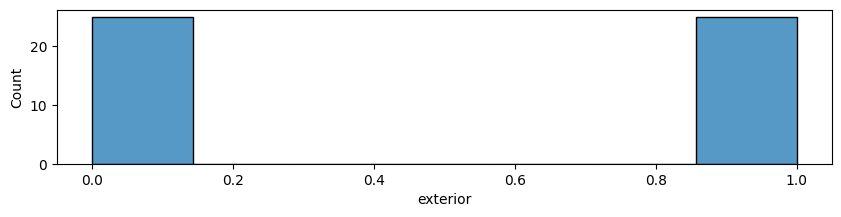

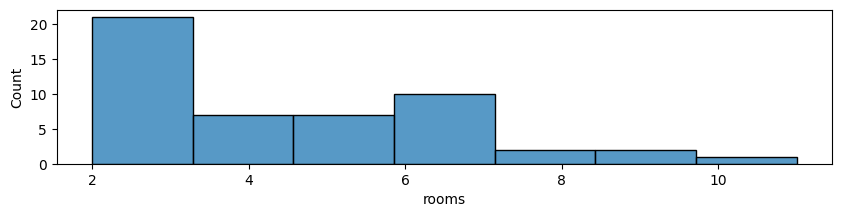

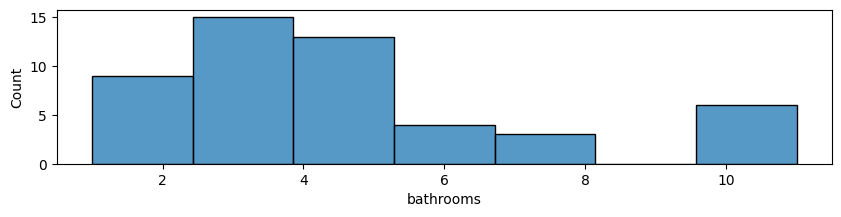

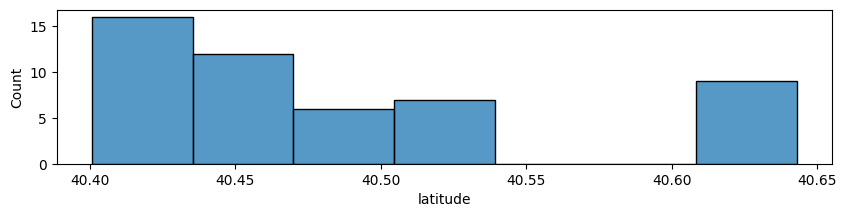

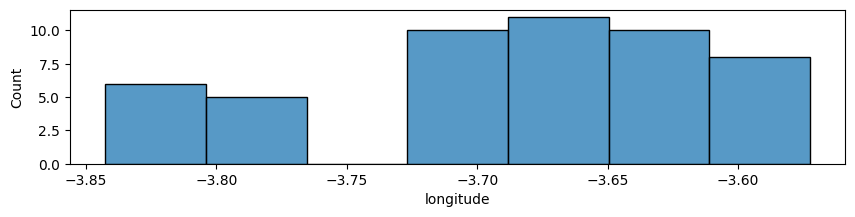

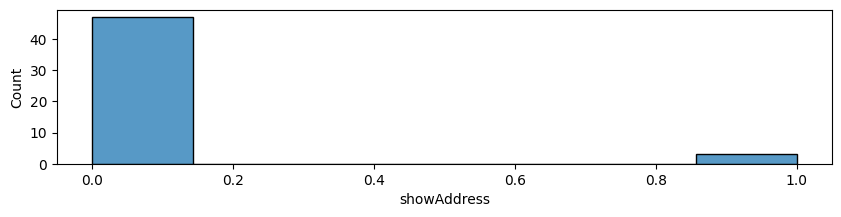

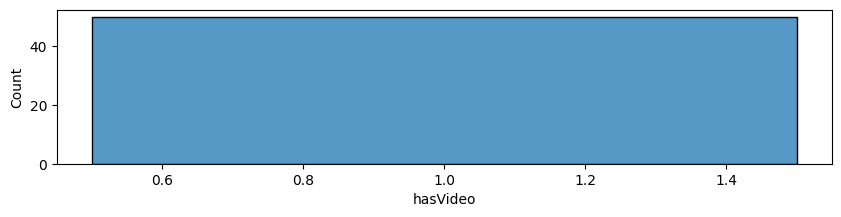

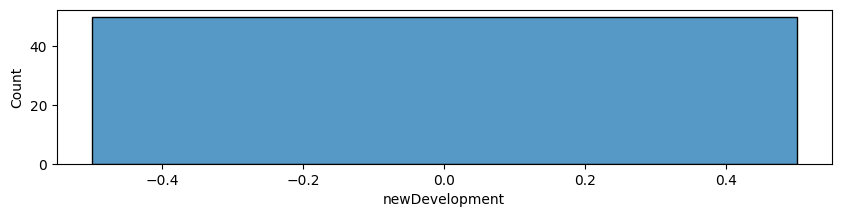

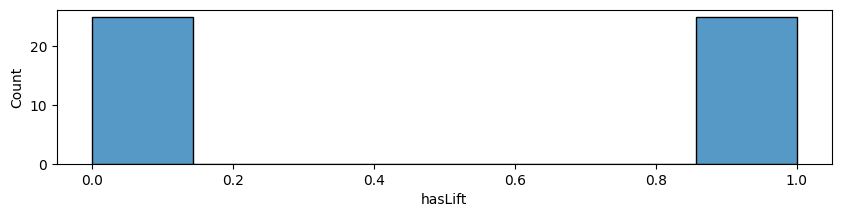

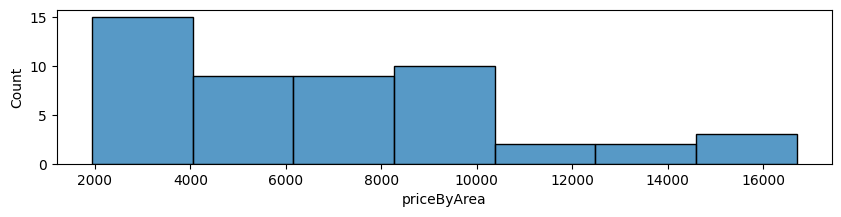

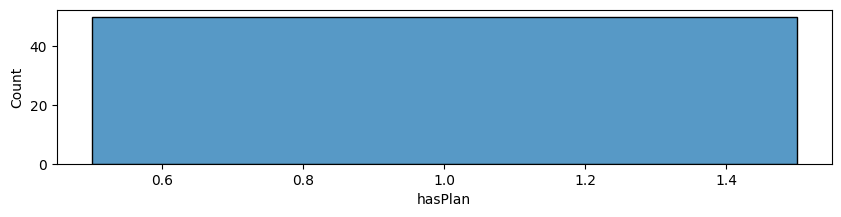

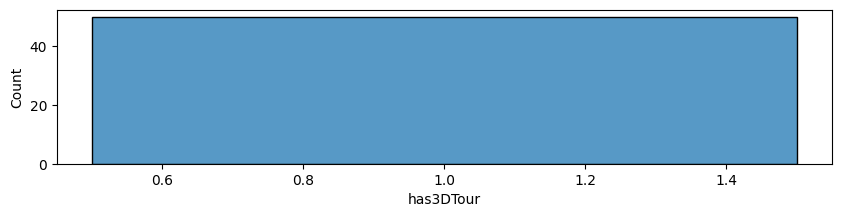

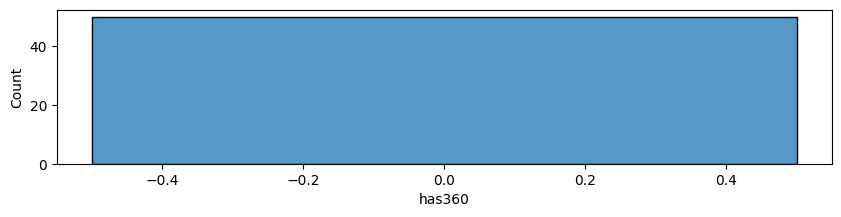

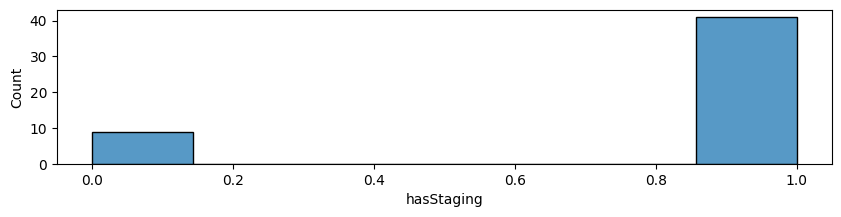

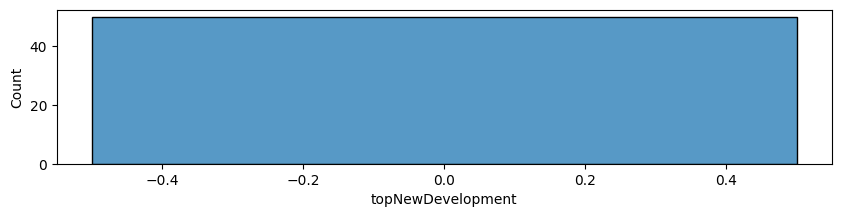

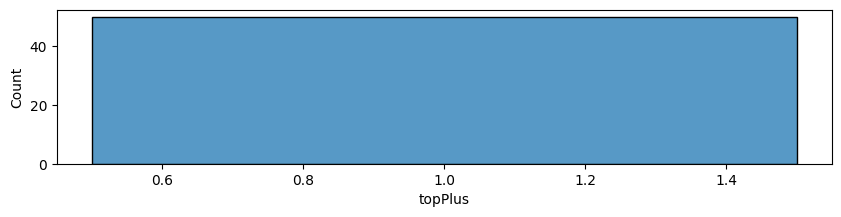

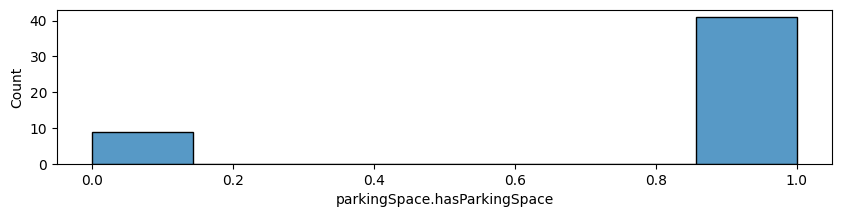

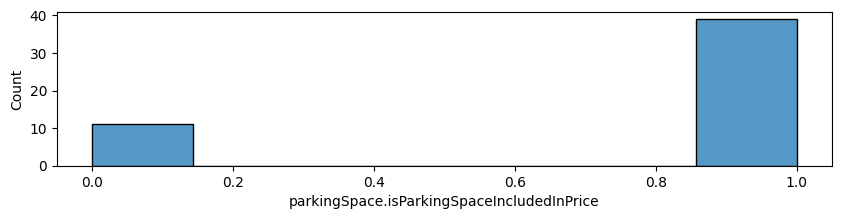

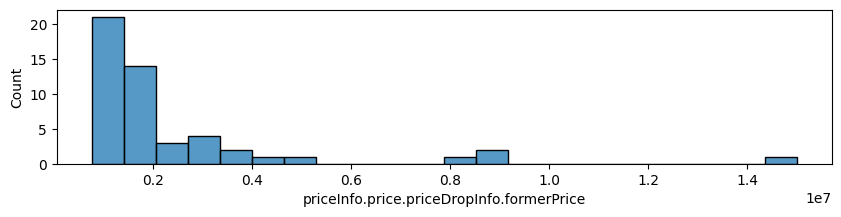

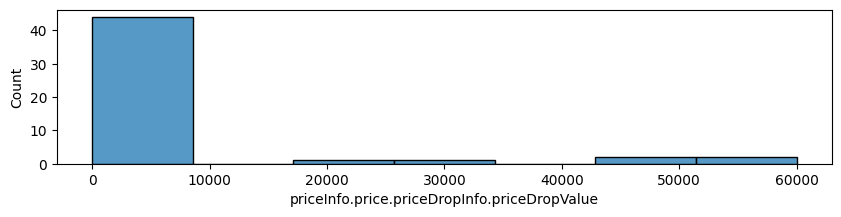

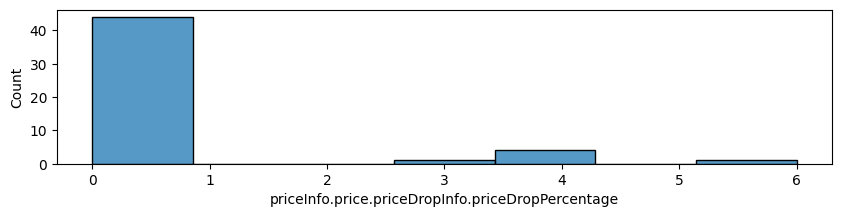

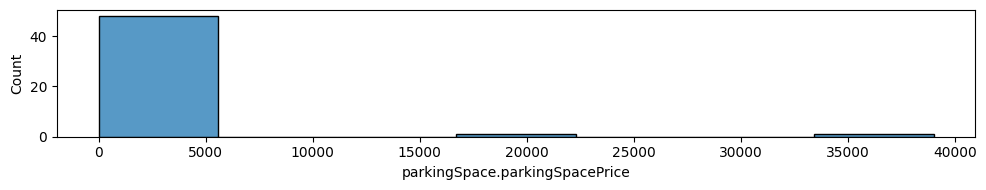

In [ ]:
# Graficamos las distribuciones de las variables numéricas
for col in variables_numericas:
    plt.figure(figsize=(10, 2))
    sns.histplot(data=df_datos_8, x=col)

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
"""
for col in variables_numericas:
    plt.figure(figsize=(10, 2))
    sns.histplot(data=df_datos_8, x=col, hue=var_obj)

plt.savefig('vn.png', format='png', dpi=300)
plt.show()
plt.close()
"""

"\nfor col in variables_numericas:\n    plt.figure(figsize=(10, 2))\n    sns.histplot(data=df_datos_8, x=col, hue=var_obj)\n\nplt.savefig('vn.png', format='png', dpi=300)\nplt.show()\nplt.close()\n"

### Clustering

Evaluando diferentes combinaciones de Clustering.
Puntos a tener en cuenta. OHE agrega más dimensionalidad -> más datos, complejidad de procesamiento es mayor.
Para realizar Clustering utilizaremos diferentes variantes y observaremos resultados, descartando las que no sirvan:
Clusterings a probar:
1. District(Object), Room(num), Bathroom (num) -> utilizando OHE+KMeans
2. District(Object), Room(num), Bathroom (num) -> utilizando K-Prototypes
3.

---



In [ ]:
# Clustering: Municipality, Room, Bathroom
# df_datos_8.info()
df_datos_8["district"].nunique()

16

In [ ]:
# ONE HOT ENCODE para district
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
district_encoded = ohe.fit_transform(df_datos_8[['district']])
encoded_df = pd.DataFrame(district_encoded, columns=ohe.get_feature_names_out(['district']))


In [ ]:
encoded_df

,district_Arganzuela,district_Barrio de Salamanca,district_Centro,district_Chamartín,district_Chamberí,district_El Soto de la Moraleja,district_Encinar de los Reyes,district_Hortaleza,district_La Moraleja urbanización,district_Moncloa,district_Retiro,district_Urbanizaciones,district_Zona Estación,district_Zona Prado de Somosaguas - La Finca,district_Zona Pueblo,district_unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Diseñado del modelo DL

In [ ]:
df_datos_9 = df_datos_8.copy()

In [ ]:
# Separar X e y
X = df_datos_9
y = var_obj

#Separar numericas y categoricas
X_num = df_datos_9[variables_numericas].copy()
X_cat = df_datos_9[variables_categoricas].copy()

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Codificar categóricas como one-hot (más fácil al principio)
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combinar
X_preprocessed = np.concatenate([X_num_scaled, X_cat_encoded.values], axis=1)

# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

##### Modelo secuencial ANN Binaria

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

model = tf.keras.models.Sequential()

# Capa 1
model.add(layers.Dense(64, activation='relu',
                       input_shape=(x_train.shape[1],),
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 2
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 3
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 4
model.add(layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))

# Capa de salida para clasificación binaria
model.add(layers.Dense(1, activation='sigmoid'))

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Entrenamiento
batch_size = 64
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1,
          callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
          ])

# Evaluación
results = model.evaluate(x_test, y_test, verbose=1)
print(f'\nTest Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f} | Precision: {results[3]:.4f} | Recall: {results[4]:.4f}')

In [ ]:
# Guardar probabilidad de venta
df_features = preprocessor.transform(X)
df['prob_vendido'] = model.predict(df_features).flatten()

# Opcional: guardar
df.to_csv("viviendas_con_predicciones.csv", index=False)
model.save("modelo_clasificador.h5")

##### Modelo secuencial ANN Regression

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

model = tf.keras.models.Sequential()

# Capa 1
model.add(layers.Dense(64, activation='relu',
                       input_shape=(x_train.shape[1],),
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 2
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 3
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))
model.add(layers.Dropout(0.4))

# Capa 4
model.add(layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(5e-4)))

# Capa de salida para regresión (sin activación)
model.add(layers.Dense(1))

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', 'mse']
)

# Entrenamiento
batch_size = 64
model.fit(x_train,
          y_train,
          epochs=200,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1,
          callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
          ])

# Evaluación
results = model.evaluate(x_test, y_test, verbose=1)
print(f'\nTest Loss: {results[0]:.4f} | MAE: {results[1]:.4f} | MSE: {results[2]:.4f}')


##### Ft-transform (Vemos cual da mejor resultado entre los dos para usarlo despues)

In [ ]:
#!pip install pytorch-tabular

from pytorch_tabular import TabularModel
from pytorch_tabular.models.ft_transformer import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd

# Detectar variables
target = "vendido"
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
continuous_cols = df.select_dtypes(include=["int64", "float64"]).drop(columns=[target]).columns.tolist()

# Configuración del dataset
data_config = DataConfig(
    target=target,
    continuous_cols=continuous_cols,
    categorical_cols=categorical_cols,
    normalize_continuous_features=True,
)

# Configuración del modelo FT-Transformer
model_config = FTTransformerConfig(
    task="classification",
    learning_rate=1e-3,
    metrics=["accuracy", "auc"],
    num_attention_heads=4,
    transformer_hidden_dim=64,
    input_embed_dim=32,
    num_layers=4,
)

trainer_config = TrainerConfig(
    auto_lr_find=True,
    batch_size=64,
    max_epochs=100,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    gpus=0  # Usa 1 si tienes GPU en Colab
)

# Construir y entrenar el modelo
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    trainer_config=trainer_config,
)

tabular_model.fit(df)

# Predecir y guardar probabilidad de venta
pred_df = tabular_model.predict(df)
df['prob_vendido'] = pred_df['prediction_probability'].values
df['clasificacion'] = df['prob_vendido'].apply(
    lambda x: "Excelente" if x > 0.8 else ("Buena" if x > 0.6 else "Mala")
)

# Guardar
df.to_csv("viviendas_con_fttransformer.csv", index=False)

#### IA Generativa (Ejemplo, habra que cambiarlo segun los datos)

In [ ]:
#IA
preferencias = {
    'zona': 'Centro',
    'habitaciones_min': 2,
    'precio_max': 300000
}

df_recomendadas = df[
    (df['zona'] == preferencias['zona']) &
    (df['habitaciones'] >= preferencias['habitaciones_min']) &
    (df['precio'] <= preferencias['precio_max']) &
    (df['clasificacion'].isin(['Buena', 'Excelente']))
]

In [ ]:
pip install selenium

In [ ]:
import pandas as pd
from pandas import json_normalize

# Lista de viviendas dentro del JSON
viviendas = data_json["elementList"]

# Usamos json_normalize con sep='.' para que las claves anidadas se aplanen con ese separador
df = json_normalize(viviendas, sep='.')

# Mostrar columnas finales del DataFrame
print("Columnas limpias del DataFrame:")
df